## EDA - Dataset Climatológico SMN

Análisis Exploratorio de Datos sobre registros históricos del **Servicio Meteorológico Nacional**.
El dataset contiene información de **98 estaciones meteorológicas** con variables climáticas mensuales.


### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency


### Carga del dataset

In [2]:
df = pd.read_csv('smn_historico.csv')

# Convertir 'S/D' (sin dato) a NaN y castear a numérico
cols_num = ['humedad', 'prec_mm', 'temp', 'temp_max', 'temp_min', 'viento', 'nubosidad', 'prec_sup_1mm']
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dimensiones del dataset: {df.shape}')
df.head()


Dimensiones del dataset: (1176, 16)


,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   estacion      1176 non-null   str    
 1   provincia     1152 non-null   str    
 2   altura        1152 non-null   float64
 3   numero        1152 non-null   float64
 4   NroOACI       1140 non-null   str    
 5   LAT_decimal   1152 non-null   float64
 6   LON_decimal   1152 non-null   float64
 7   mes_txt       1176 non-null   str    
 8   prec_sup_1mm  1061 non-null   float64
 9   humedad       1110 non-null   float64
 10  nubosidad     1166 non-null   float64
 11  prec_mm       1061 non-null   float64
 12  temp          1167 non-null   float64
 13  temp_max      1158 non-null   float64
 14  temp_min      1124 non-null   float64
 15  viento        708 non-null    float64
dtypes: float64(12), str(4)
memory usage: 147.1 KB


In [4]:
# Valores nulos por columna
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
print(pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct}))


              Nulos  Porcentaje (%)
estacion          0            0.00
provincia        24            2.04
altura           24            2.04
numero           24            2.04
NroOACI          36            3.06
LAT_decimal      24            2.04
LON_decimal      24            2.04
mes_txt           0            0.00
prec_sup_1mm    115            9.78
humedad          66            5.61
nubosidad        10            0.85
prec_mm         115            9.78
temp              9            0.77
temp_max         18            1.53
temp_min         52            4.42
viento          468           39.80


In [10]:
# Variables del dataset y su tipo
variables = {
    'estacion':      'Nominal   — categorías sin orden',
    'temp':          'Continua  — valores reales (°C)',
    'prec_mm':       'Continua  — valores reales (mm)',
    'alerta':        'Ordinal   — bajo < medio < alto',
}
for var, tipo in variables.items():
    print(f'  {var:15} : {tipo}')


  estacion        : Nominal   — categorías sin orden
  temp            : Continua  — valores reales (°C)
  prec_mm         : Continua  — valores reales (mm)
  alerta          : Ordinal   — bajo < medio < alto


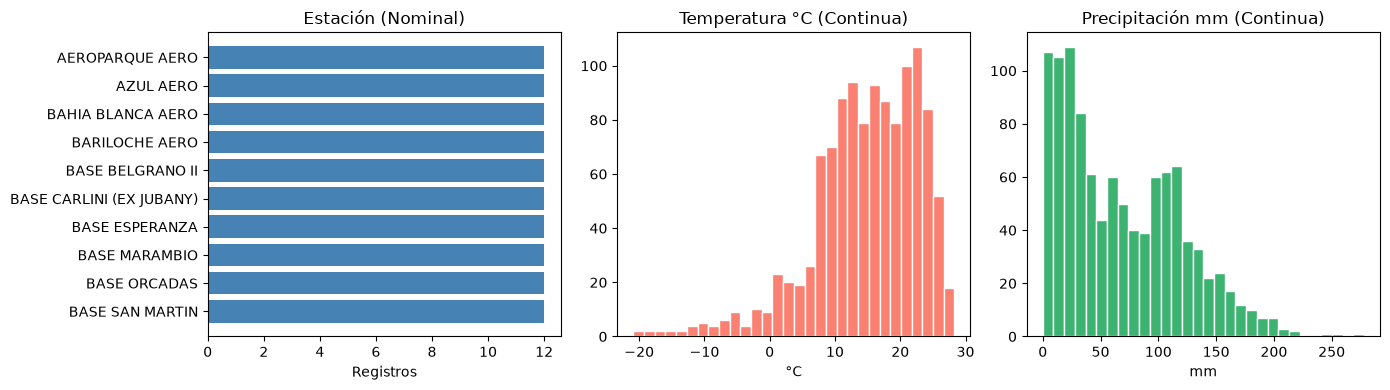

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Estación (nominal) top 10
top_est = df['estacion'].value_counts().head(10)
axes[0].barh(top_est.index[::-1], top_est.values[::-1], color='steelblue')
axes[0].set_title('Estación (Nominal)')
axes[0].set_xlabel('Registros')

# Temperatura (continua)
axes[1].hist(df['temp'].dropna(), bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Temperatura °C (Continua)')
axes[1].set_xlabel('°C')

# Precipitación (continua)
axes[2].hist(df['prec_mm'].dropna(), bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Precipitación mm (Continua)')
axes[2].set_xlabel('mm')

plt.tight_layout()
plt.show()


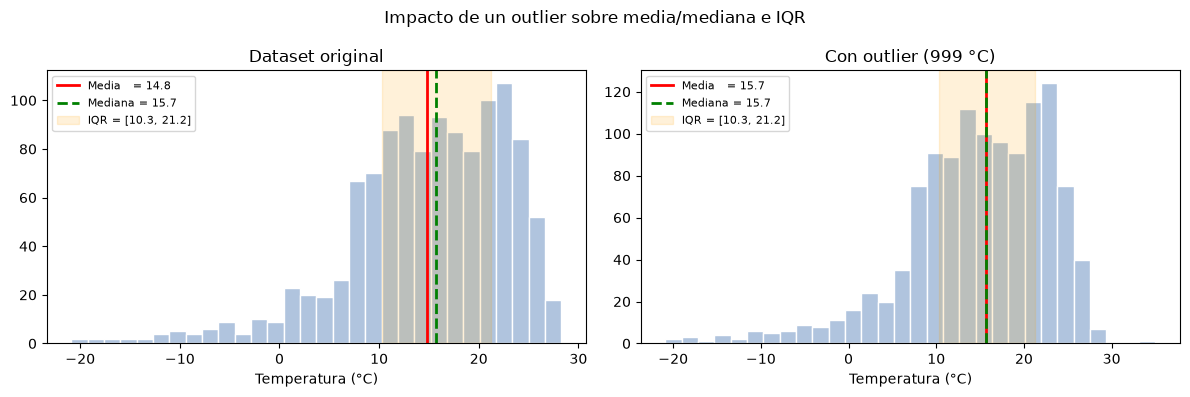

Sin outlier  → Media: 14.83  | Mediana: 15.70  | Std: 8.18
Con outlier  → Media: 15.68 | Mediana: 15.70  | Std: 29.93


In [12]:
temp = df['temp'].dropna()
temp_con_outlier = pd.concat([temp, pd.Series([999])], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, titulo in zip(axes,
                             [temp, temp_con_outlier],
                             ['Dataset original', 'Con outlier (999 °C)']):
    media   = data.mean()
    mediana = data.median()
    q1, q3  = data.quantile(0.25), data.quantile(0.75)

    ax.hist(data.clip(upper=35), bins=30, color='lightsteelblue', edgecolor='white')
    ax.axvline(media,   color='red',    lw=2, label=f'Media   = {media:.1f}')
    ax.axvline(mediana, color='green',  lw=2, linestyle='--', label=f'Mediana = {mediana:.1f}')
    ax.axvspan(q1, q3,  alpha=0.15, color='orange', label=f'IQR = [{q1:.1f}, {q3:.1f}]')
    ax.set_title(titulo)
    ax.set_xlabel('Temperatura (°C)')
    ax.legend(fontsize=8)

plt.suptitle('Impacto de un outlier sobre media/mediana e IQR', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Sin outlier  → Media: {temp.mean():.2f}  | Mediana: {temp.median():.2f}  | Std: {temp.std():.2f}')
print(f'Con outlier  → Media: {temp_con_outlier.mean():.2f} | Mediana: {temp_con_outlier.median():.2f}  | Std: {temp_con_outlier.std():.2f}')


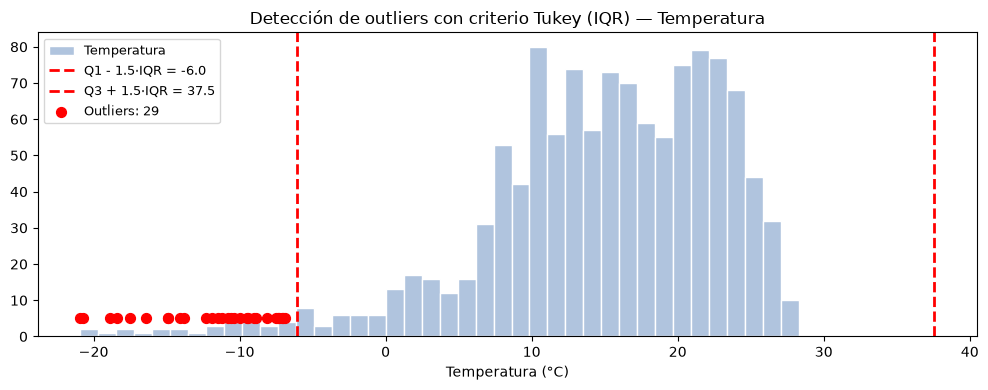

Q1=10.3  Q3=21.2  IQR=10.9
Límites: [-6.0, 37.5]
Outliers encontrados: 29
[ -7.1 -12.3 -16.4 -17.5 -18.9 -20.9 -20.7 -18.4 -14.1  -7.   -7.4 -10.4
 -10.8  -9.5  -6.9 -10.  -11.9 -14.9 -14.9 -13.8 -10.6  -7.3  -7.5  -9.4
  -8.1  -8.9 -11.5 -11.2  -9. ]


In [13]:
data = df['temp'].dropna()
q1, q3 = data.quantile(0.25), data.quantile(0.75)
iqr    = q3 - q1
lim_lo = q1 - 1.5 * iqr
lim_hi = q3 + 1.5 * iqr

outliers = data[(data < lim_lo) | (data > lim_hi)]

plt.figure(figsize=(10, 4))
plt.hist(data, bins=40, color='lightsteelblue', edgecolor='white', label='Temperatura')
plt.axvline(lim_lo, color='red', lw=2, linestyle='--', label=f'Q1 - 1.5·IQR = {lim_lo:.1f}')
plt.axvline(lim_hi, color='red', lw=2, linestyle='--', label=f'Q3 + 1.5·IQR = {lim_hi:.1f}')
plt.scatter(outliers, [5]*len(outliers), color='red', zorder=5, s=50, label=f'Outliers: {len(outliers)}')
plt.title('Detección de outliers con criterio Tukey (IQR) — Temperatura')
plt.xlabel('Temperatura (°C)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Q1={q1:.1f}  Q3={q3:.1f}  IQR={iqr:.1f}')
print(f'Límites: [{lim_lo:.1f}, {lim_hi:.1f}]')
print(f'Outliers encontrados: {len(outliers)}')
if len(outliers): print(outliers.values)


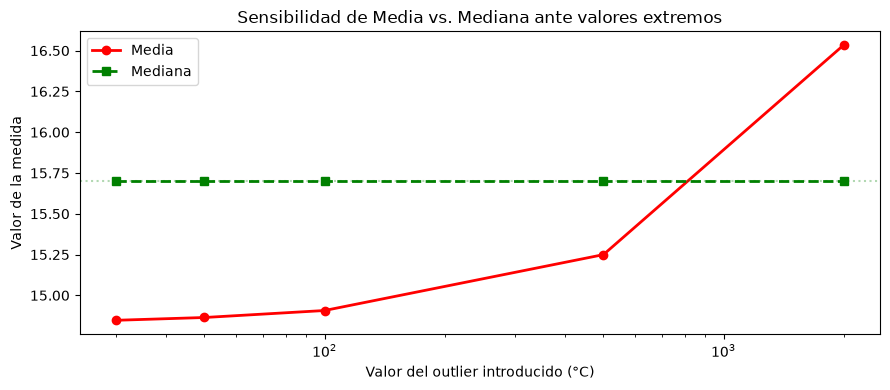

In [14]:
base = df['temp'].dropna().values
outlier_vals = [30, 50, 100, 500, 2000]

medias   = [np.append(base, ov).mean()   for ov in outlier_vals]
medianas = [np.median(np.append(base, ov)) for ov in outlier_vals]

plt.figure(figsize=(9, 4))
plt.plot(outlier_vals, medias,   'o-', color='red',   lw=2, label='Media')
plt.plot(outlier_vals, medianas, 's--', color='green', lw=2, label='Mediana')
plt.axhline(np.median(base), color='green', alpha=0.3, linestyle=':')
plt.xlabel('Valor del outlier introducido (°C)')
plt.ylabel('Valor de la medida')
plt.title('Sensibilidad de Media vs. Mediana ante valores extremos')
plt.xscale('log')
plt.legend()
plt.tight_layout()
plt.show()


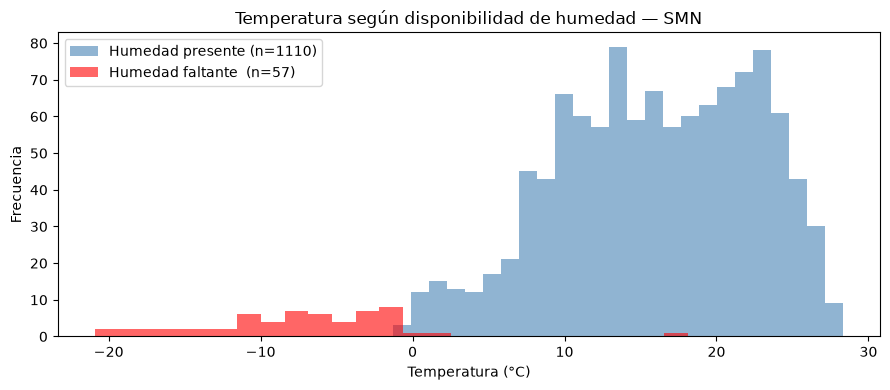

Temp media con humedad:    15.97 °C
Temp media sin humedad:    -7.25 °C

→ MAR: la ausencia de humedad está asociada a temperaturas bajas (variable observable).
  No depende del propio valor de humedad → se puede imputar condicionalmente.


In [15]:
# Distribución de temperatura según si humedad está presente o no
temp_con = df.loc[df['humedad'].notna(), 'temp'].dropna()
temp_sin = df.loc[df['humedad'].isna(),  'temp'].dropna()

plt.figure(figsize=(9, 4))
plt.hist(temp_con, bins=25, alpha=0.6, color='steelblue', label=f'Humedad presente (n={len(temp_con)})')
plt.hist(temp_sin, bins=25, alpha=0.6, color='red',       label=f'Humedad faltante  (n={len(temp_sin)})')
plt.title('Temperatura según disponibilidad de humedad — SMN')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Temp media con humedad:    {temp_con.mean():.2f} °C')
print(f'Temp media sin humedad:    {temp_sin.mean():.2f} °C')
print()
print('→ MAR: la ausencia de humedad está asociada a temperaturas bajas (variable observable).')
print('  No depende del propio valor de humedad → se puede imputar condicionalmente.')


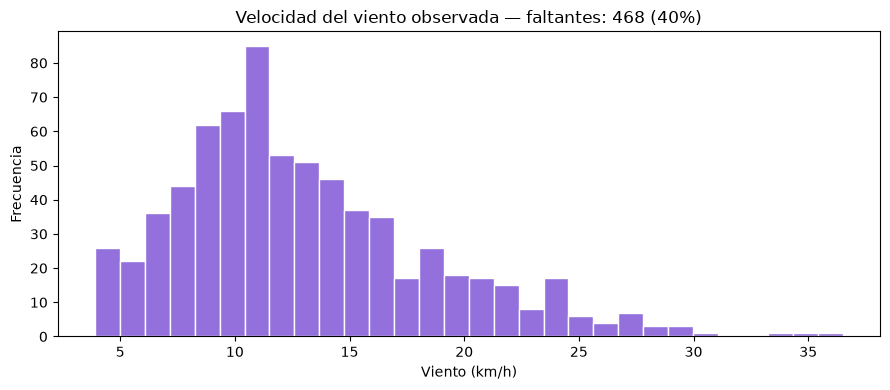

Registros observados: 708  |  Faltantes: 468 (39.8%)

→ MNAR: el sensor se satura cuando el viento ES extremo.
  La causa del faltante es el propio valor → no se puede corregir sin info externa.


In [16]:
n_total  = len(df)
n_falt   = df['viento'].isna().sum()
n_obs    = df['viento'].notna().sum()

plt.figure(figsize=(9, 4))
plt.hist(df['viento'].dropna(), bins=30, color='mediumpurple', edgecolor='white')
plt.title(f'Velocidad del viento observada — faltantes: {n_falt} ({100*n_falt/n_total:.0f}%)')
plt.xlabel('Viento (km/h)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print(f'Registros observados: {n_obs}  |  Faltantes: {n_falt} ({100*n_falt/n_total:.1f}%)')
print()
print('→ MNAR: el sensor se satura cuando el viento ES extremo.')
print('  La causa del faltante es el propio valor → no se puede corregir sin info externa.')


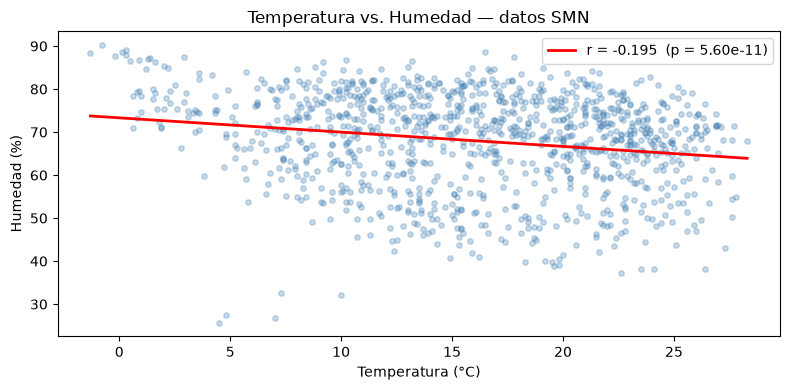

Pearson r = -0.1950
p-valor   = 5.60e-11

→ r ≈ -0.19: relación lineal muy débil. No hay patrón lineal claro.
  El r negativo es válido (no indica error), solo que la tendencia es inversa y leve.


In [17]:
sub = df[['temp', 'humedad']].dropna()
r, p = stats.pearsonr(sub['temp'], sub['humedad'])

plt.figure(figsize=(8, 4))
plt.scatter(sub['temp'], sub['humedad'], alpha=0.3, s=15, color='steelblue')
m, b = np.polyfit(sub['temp'], sub['humedad'], 1)
x = np.linspace(sub['temp'].min(), sub['temp'].max(), 100)
plt.plot(x, m*x+b, color='red', lw=2, label=f'r = {r:.3f}  (p = {p:.2e})')
plt.title('Temperatura vs. Humedad — datos SMN')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Humedad (%)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Pearson r = {r:.4f}')
print(f'p-valor   = {p:.2e}')
print()
print('→ r ≈ -0.19: relación lineal muy débil. No hay patrón lineal claro.')
print('  El r negativo es válido (no indica error), solo que la tendencia es inversa y leve.')


        Métrica  Con 333 (error)  Con 66 (correcto)      Δ
          Media            39.03              30.13  -8.90
        Mediana            28.00              28.00   0.00
Desvío estándar            54.84               8.45 -46.39
            IQR             8.75               8.75   0.00


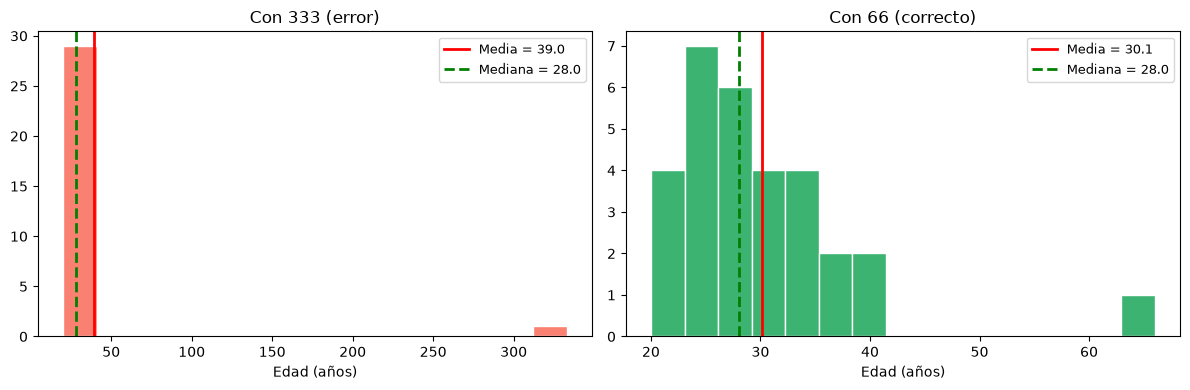

In [18]:
np.random.seed(7)
edades_error    = np.random.randint(20, 40, size=29).tolist() + [333]
edades_correcto = edades_error[:-1] + [66]

arr_e = np.array(edades_error)
arr_c = np.array(edades_correcto)

resumen = pd.DataFrame({
    'Métrica': ['Media', 'Mediana', 'Desvío estándar', 'IQR'],
    'Con 333 (error)':    [arr_e.mean(), np.median(arr_e), arr_e.std(), np.percentile(arr_e,75)-np.percentile(arr_e,25)],
    'Con 66 (correcto)':  [arr_c.mean(), np.median(arr_c), arr_c.std(), np.percentile(arr_c,75)-np.percentile(arr_c,25)],
}).round(2)
resumen['Δ'] = (resumen['Con 66 (correcto)'] - resumen['Con 333 (error)']).round(2)
print(resumen.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, arr, titulo, color in zip(axes, [arr_e, arr_c],
                                   ['Con 333 (error)', 'Con 66 (correcto)'],
                                   ['salmon', 'mediumseagreen']):
    ax.hist(arr, bins=15, color=color, edgecolor='white')
    ax.axvline(arr.mean(),       color='red',   lw=2, label=f'Media = {arr.mean():.1f}')
    ax.axvline(np.median(arr),   color='green', lw=2, linestyle='--', label=f'Mediana = {np.median(arr):.1f}')
    ax.set_title(titulo)
    ax.set_xlabel('Edad (años)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


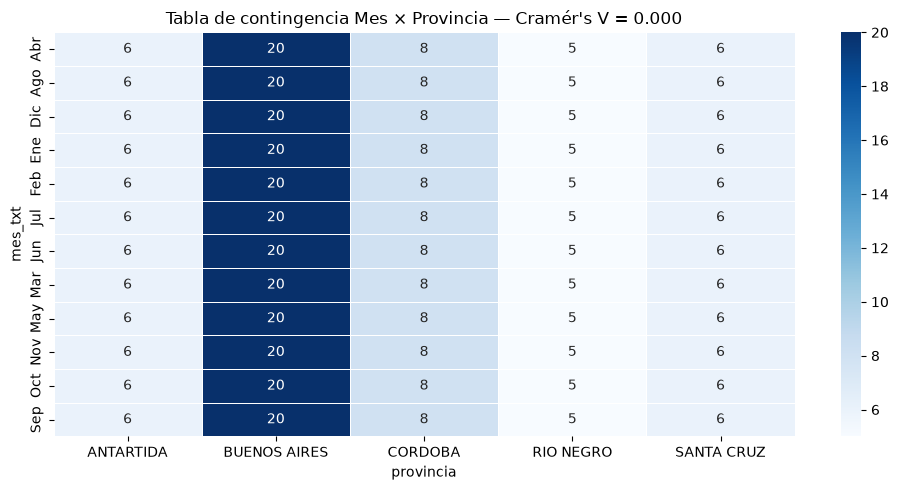

Chi²       = 0.00
p-valor    = 1.0000
Cramér's V = 0.0000  → asociación baja


In [19]:
# Usamos mes (ordinal) y provincia (nominal) del dataset SMN
orden_mes = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
df_asoc = df[df['mes_txt'].isin(orden_mes) & df['provincia'].notna()].copy()

top_prov = df_asoc['provincia'].value_counts().head(5).index
df_top   = df_asoc[df_asoc['provincia'].isin(top_prov)]

tabla = pd.crosstab(df_top['mes_txt'], df_top['provincia'])
chi2, p, dof, _ = chi2_contingency(tabla)
n = tabla.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

plt.figure(figsize=(10, 5))
sns.heatmap(tabla, annot=True, fmt='d', cmap='Blues', linewidths=0.4)
plt.title(f"Tabla de contingencia Mes × Provincia — Cramér's V = {cramers_v:.3f}")
plt.tight_layout()
plt.show()

print(f"Chi²       = {chi2:.2f}")
print(f"p-valor    = {p:.4f}")
print(f"Cramér's V = {cramers_v:.4f}  → asociación {'baja' if cramers_v < 0.2 else 'moderada'}")


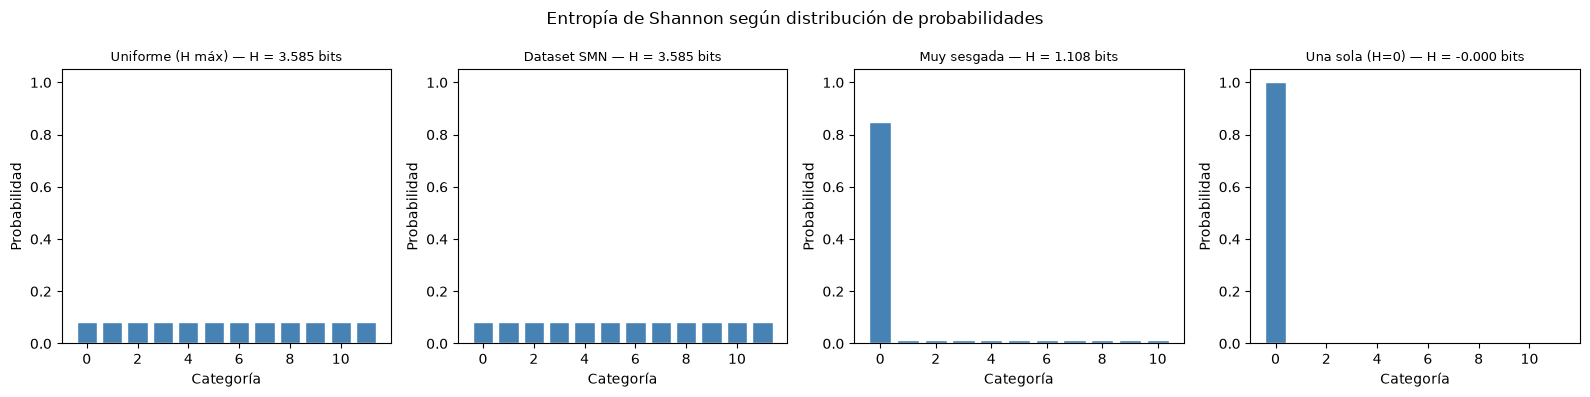

In [21]:
def entropia(probs):
    probs = np.array([p for p in probs if p > 0])
    return -np.sum(probs * np.log2(probs))

distribuciones = {
    'Uniforme (H máx)':  [1/12] * 12,
    'Dataset SMN':        (df['mes_txt'].value_counts(normalize=True)
                           .reindex(orden_mes).fillna(0).values.tolist()),
    'Muy sesgada':        [0.85] + [0.015]*10,
    'Una sola (H=0)':     [1.0]  + [0.0]*11,
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (titulo, probs) in zip(axes, distribuciones.items()):
    probs = np.array(probs) / np.sum(probs)
    H = entropia(probs)
    ax.bar(range(len(probs)), probs, color='steelblue', edgecolor='white')
    ax.set_title(f'{titulo} — H = {H:.3f} bits', fontsize=9)
    ax.set_xlabel('Categoría')
    ax.set_ylabel('Probabilidad')
    ax.set_ylim(0, 1.05)

plt.suptitle('Entropía de Shannon según distribución de probabilidades', fontsize=12)
plt.tight_layout()
plt.show()

---
### Resumen de respuestas

| # | Respuesta correcta |
|---|-------------------|
| 1 | **C** — Estación: nominal · Temperatura: continua · Precipitación: continua · Alerta: ordinal |
| 2 | **B** — Mediana e IQR son menos sensibles a valores extremos |
| 3 | **B** — Q1 − 1.5·IQR / Q3 + 1.5·IQR (Tukey) |
| 4 | **B** — La mediana es más robusta que la media ante outliers |
| 5 | **B** — MAR (depende de temperatura, variable observable) |
| 6 | **C** — MNAR (el propio valor extremo causa la ausencia) |
| 7 | **B** — Sin relación lineal significativa; r negativo es válido |
| 8 | **B** — Disminuye la media Y la desviación estándar |
| 9 | **B** — Cramér's V |
| 10 | **A** — Máxima cuando todas las categorías son equiprobables |
